# NSE Data Fetcher
Fetches historical stock data from NSE via `yfinance` and saves as CSV.

**Smart company resolution**: type any natural name — `cipla`, `reliance`, `asian paints`,
`bajaj finance`, `relaince` (typo) — and the notebook resolves it to the correct NSE symbol automatically.

In [69]:
# ─────────────────────────────────────────────────────────────────────────────
# TWEAK THESE  ▶  type any natural company name or NSE symbol below
# ─────────────────────────────────────────────────────────────────────────────
COMPANY_INPUT = "cipla"       # e.g. "cipla", "asian paints", "bajaj finance",
                              #       "tata consult", "relaince", "TCS"
START_DATE    = "2020-01-01"  # YYYY-MM-DD
END_DATE      = "2026-01-01"  # YYYY-MM-DD
INTERVAL      = "1d"          # 1m 5m 15m 30m 1h 1d 1wk 1mo
OUTPUT_DIR    = "nse_data"    # folder created next to this notebook
# ─────────────────────────────────────────────────────────────────────────────


In [70]:
import subprocess, sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# yfinance
try:
    import yfinance
except ImportError:
    _pip_install("yfinance")
    import yfinance

# rapidfuzz  (fast, MIT-licensed fuzzy matching)
try:
    from rapidfuzz import fuzz, process as rfprocess
except ImportError:
    _pip_install("rapidfuzz")
    from rapidfuzz import fuzz, process as rfprocess

print("Dependencies ready.")


Dependencies ready.


In [71]:
import re

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1 ─ Normalization
# ───────────────────────────────────────────────────────────────────────────────
# Only strip TRULY useless corporate-form suffixes.
# Meaningful words (bank, finance, tech, pharma, steel …) are KEPT so that
# "bajaj finance" stays distinct from "bajaj auto" and "tech mahindra" is never
# confused with "mahindra & mahindra".
# ═══════════════════════════════════════════════════════════════════════════════

_SUFFIX_RE = re.compile(r"\b(ltd|limited|inc|corp|corporation|plc|pvt|private)\b")

def _normalize(text: str) -> str:
    """Lowercase, remove punctuation noise, strip useless corporate suffixes."""
    text = text.lower().strip()
    text = re.sub(r"[._\-+]", " ", text)          # dots / dashes / underscores → space
    text = re.sub(r"[^a-z0-9&\s]", "", text)       # remove all other specials
    text = _SUFFIX_RE.sub("", text)                 # strip ltd / limited / inc / plc …
    return re.sub(r"\s+", " ", text).strip()       # collapse whitespace


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2 ─ Alias dictionary  (NSE F&O + large-cap universe)
# ───────────────────────────────────────────────────────────────────────────────
# Keys: lowercase natural names / short forms / abbreviations
# Values: canonical NSE ticker symbol (exactly as it appears on exchange)
# ═══════════════════════════════════════════════════════════════════════════════

_COMPANY_MAP: dict[str, str] = {
    # ── A ─────────────────────────────────────────────────────────────────────
    "abbotindia": "ABBOTINDIA", "abbott india": "ABBOTINDIA",
    "aartiind": "AARTIIND", "aarti industries": "AARTIIND",
    "aarti ind": "AARTIIND", "aarti": "AARTIIND",
    "adaniports": "ADANIPORTS", "adani ports": "ADANIPORTS",
    "adanient": "ADANIENT", "adani enterprises": "ADANIENT",
    "adani ent": "ADANIENT",
    "adanigreen": "ADANIGREEN", "adani green": "ADANIGREEN",
    "adanipower": "ADANIPOWER", "adani power": "ADANIPOWER",
    "adanitrans": "ADANITRANS", "adani transmission": "ADANITRANS",
    "alkem": "ALKEM", "alkem labs": "ALKEM", "alkem laboratories": "ALKEM",
    "amber": "AMBER", "amber enterprises": "AMBER",
    "apollohosp": "APOLLOHOSP", "apollo hospitals": "APOLLOHOSP",
    "apollo hospital": "APOLLOHOSP", "apollo": "APOLLOHOSP",
    "apollotyre": "APOLLOTYRE", "apollo tyre": "APOLLOTYRE",
    "apollo tyres": "APOLLOTYRE",
    # ── ASIANPAINT ────────────────────────────────────────────────────────────
    "asianpaint": "ASIANPAINT", "asian paints": "ASIANPAINT",
    "asian paint": "ASIANPAINT", "asian": "ASIANPAINT",
    # ─────────────────────────────────────────────────────────────────────────
    "auropharma": "AUROPHARMA", "aurobindo pharma": "AUROPHARMA",
    "aurobindo": "AUROPHARMA",
    "axisbank": "AXISBANK", "axis bank": "AXISBANK", "axis": "AXISBANK",
    # ── B ─────────────────────────────────────────────────────────────────────
    "bajaj-auto": "BAJAJ-AUTO", "bajaj auto": "BAJAJ-AUTO",
    "bajajfinsv": "BAJAJFINSV", "bajaj finserv": "BAJAJFINSV",
    "bajaj finsv": "BAJAJFINSV",
    "bajfinance": "BAJFINANCE", "bajaj finance": "BAJFINANCE",
    "bajaj fin": "BAJFINANCE",
    "bandhanbnk": "BANDHANBNK", "bandhan bank": "BANDHANBNK",
    "bandhan": "BANDHANBNK",
    "bankbaroda": "BANKBARODA", "bank of baroda": "BANKBARODA",
    "bob": "BANKBARODA",
    "bergepaint": "BERGEPAINT", "berger paints": "BERGEPAINT",
    "berger paint": "BERGEPAINT", "berger": "BERGEPAINT",
    "bhel": "BHEL", "bharat heavy electricals": "BHEL",
    "biocon": "BIOCON",
    "bpcl": "BPCL", "bharat petroleum": "BPCL",
    "britannia": "BRITANNIA",
    # ── C ─────────────────────────────────────────────────────────────────────
    "canbk": "CANBK", "canara bank": "CANBK", "canara": "CANBK",
    "cipla": "CIPLA",
    "coalindia": "COALINDIA", "coal india": "COALINDIA",
    "colpal": "COLPAL", "colgate palmolive": "COLPAL", "colgate": "COLPAL",
    "cumminsind": "CUMMINSIND", "cummins india": "CUMMINSIND",
    "cummins": "CUMMINSIND",
    # ── D ─────────────────────────────────────────────────────────────────────
    "dabur": "DABUR",
    "deepakntr": "DEEPAKNTR", "deepak nitrite": "DEEPAKNTR",
    "deepak": "DEEPAKNTR",
    "divislab": "DIVISLAB", "divis labs": "DIVISLAB",
    "divis lab": "DIVISLAB", "divis": "DIVISLAB",
    "dmart": "DMART", "avenue supermarts": "DMART",
    "avenue supermart": "DMART",
    "drreddy": "DRREDDY", "dr reddys": "DRREDDY", "dr reddy": "DRREDDY",
    "dr reddys laboratories": "DRREDDY", "dr reddys labs": "DRREDDY",
    # ── E ─────────────────────────────────────────────────────────────────────
    "eichermot": "EICHERMOT", "eicher motors": "EICHERMOT",
    "eicher": "EICHERMOT",
    "emamiltd": "EMAMILTD", "emami": "EMAMILTD",
    # ── F ─────────────────────────────────────────────────────────────────────
    "federalbnk": "FEDERALBNK", "federal bank": "FEDERALBNK",
    "fsn": "FSN", "nykaa": "FSN",
    # ── G ─────────────────────────────────────────────────────────────────────
    "glenmark": "GLENMARK",
    "godrejcp": "GODREJCP", "godrej consumer": "GODREJCP",
    "godrej consumer products": "GODREJCP", "godrej": "GODREJCP",
    "grasim": "GRASIM",
    # ── H ─────────────────────────────────────────────────────────────────────
    "hcltech": "HCLTECH", "hcl technologies": "HCLTECH",
    "hcl tech": "HCLTECH", "hcl": "HCLTECH",
    "hdfcbank": "HDFCBANK", "hdfc bank": "HDFCBANK", "hdfc": "HDFCBANK",
    "hdfcamc": "HDFCAMC", "hdfc amc": "HDFCAMC",
    "hdfclife": "HDFCLIFE", "hdfc life": "HDFCLIFE",
    "heromotoco": "HEROMOTOCO", "hero motocorp": "HEROMOTOCO",
    "hero moto": "HEROMOTOCO", "hero": "HEROMOTOCO",
    "hindalco": "HINDALCO",
    "hindunilvr": "HINDUNILVR", "hindustan unilever": "HINDUNILVR",
    "hul": "HINDUNILVR",
    # ── I ─────────────────────────────────────────────────────────────────────
    "icicibank": "ICICIBANK", "icici bank": "ICICIBANK", "icici": "ICICIBANK",
    "idfcfirstb": "IDFCFIRSTB", "idfc first bank": "IDFCFIRSTB",
    "idfc first": "IDFCFIRSTB",
    "indigo": "INDIGO", "interglobe aviation": "INDIGO",
    "interglobe": "INDIGO",
    "indusindbk": "INDUSINDBK", "indusind bank": "INDUSINDBK",
    "indusind": "INDUSINDBK",
    "infy": "INFY", "infosys": "INFY",
    "irctc": "IRCTC",
    "irfc": "IRFC",
    "itc": "ITC",
    # ── J ─────────────────────────────────────────────────────────────────────
    "jswsteel": "JSWSTEEL", "jsw steel": "JSWSTEEL",
    # ── K ─────────────────────────────────────────────────────────────────────
    "kotakbank": "KOTAKBANK", "kotak mahindra bank": "KOTAKBANK",
    "kotak bank": "KOTAKBANK", "kotak": "KOTAKBANK",
    # ── L ─────────────────────────────────────────────────────────────────────
    "lt": "LT", "l&t": "LT", "larsen and toubro": "LT",
    "larsen toubro": "LT", "larsen": "LT",
    "ltim": "LTIM", "ltimindtree": "LTIM", "lti mindtree": "LTIM",
    "lupin": "LUPIN",
    # ── M ─────────────────────────────────────────────────────────────────────
    "m&m": "M&M", "mahindra and mahindra": "M&M",
    "mahindra mahindra": "M&M",
    "marico": "MARICO",
    "maruti": "MARUTI", "maruti suzuki": "MARUTI",
    "mrf": "MRF",
    "muthootfin": "MUTHOOTFIN", "muthoot finance": "MUTHOOTFIN",
    "muthoot fin": "MUTHOOTFIN", "muthoot": "MUTHOOTFIN",
    # ── N ─────────────────────────────────────────────────────────────────────
    "nestleind": "NESTLEIND", "nestle india": "NESTLEIND",
    "nestle": "NESTLEIND",
    "ntpc": "NTPC",
    # ── O ─────────────────────────────────────────────────────────────────────
    "ongc": "ONGC",
    # ── P ─────────────────────────────────────────────────────────────────────
    "pageind": "PAGEIND", "page industries": "PAGEIND",
    "paytm": "PAYTM",
    "pfizer": "PFIZER",
    "pidilitind": "PIDILITIND", "pidilite industries": "PIDILITIND",
    "pidilite": "PIDILITIND",
    "pnb": "PNB", "punjab national bank": "PNB",
    "policybzr": "POLICYBZR", "policybazaar": "POLICYBZR",
    "powergrid": "POWERGRID", "power grid": "POWERGRID",
    "power grid corporation": "POWERGRID",
    # ── R ─────────────────────────────────────────────────────────────────────
    "rblbank": "RBLBANK", "rbl bank": "RBLBANK",
    "reliance": "RELIANCE", "reliance industries": "RELIANCE",
    "reliance ind": "RELIANCE", "ril": "RELIANCE",
    # ── S ─────────────────────────────────────────────────────────────────────
    "sbin": "SBIN", "sbi": "SBIN", "state bank of india": "SBIN",
    "state bank india": "SBIN", "state bank": "SBIN",
    "sbilife": "SBILIFE", "sbi life": "SBILIFE",
    "shreecem": "SHREECEM", "shree cement": "SHREECEM",
    "spicejet": "SPICEJET",
    "srf": "SRF",
    "sunpharma": "SUNPHARMA", "sun pharma": "SUNPHARMA",
    "sun pharmaceutical": "SUNPHARMA",
    "suntv": "SUNTV", "sun tv": "SUNTV",
    # ── T ─────────────────────────────────────────────────────────────────────
    "tatamotors": "TATAMOTORS", "tata motors": "TATAMOTORS",
    "tatapower": "TATAPOWER", "tata power": "TATAPOWER",
    "tatasteel": "TATASTEEL", "tata steel": "TATASTEEL",
    "tcs": "TCS", "tata consultancy services": "TCS",
    "tata consultancy": "TCS", "tata consult": "TCS",
    "techm": "TECHM", "tech mahindra": "TECHM",
    "titan": "TITAN",
    "torntpharm": "TORNTPHARM", "torrent pharma": "TORNTPHARM",
    "torrent pharmaceuticals": "TORNTPHARM",
    "torntpower": "TORNTPOWER", "torrent power": "TORNTPOWER",
    # ── U ─────────────────────────────────────────────────────────────────────
    "ultracemco": "ULTRACEMCO", "ultratech cement": "ULTRACEMCO",
    "ultratech": "ULTRACEMCO",
    "upl": "UPL",
    # ── V ─────────────────────────────────────────────────────────────────────
    "voltas": "VOLTAS",
    # ── W ─────────────────────────────────────────────────────────────────────
    "wipro": "WIPRO",
    # ── Z ─────────────────────────────────────────────────────────────────────
    "zeel": "ZEEL", "zee entertainment": "ZEEL", "zee": "ZEEL",
    "zomato": "ZOMATO",
}

# Auto-register every symbol by its own lowercase form
for _sym in list(set(_COMPANY_MAP.values())):
    _COMPANY_MAP.setdefault(_sym.lower(), _sym)

# ─────────────────────────────────────────────────────────────────────────────
# Build _NORM_MAP: normalized-key → symbol
# This is the lookup table actually used by resolve_company.
# Both keys AND user-input are normalized with _normalize() before comparison,
# so "Bajaj Finance Ltd" and "bajaj finance" both hit the same entry.
# ─────────────────────────────────────────────────────────────────────────────
_NORM_MAP: dict[str, str] = {}
for _k, _v in _COMPANY_MAP.items():
    _nk = _normalize(_k)
    _NORM_MAP.setdefault(_nk, _v)   # first writer wins (most specific alias first)

_ALL_SYMBOLS: set[str] = set(_COMPANY_MAP.values())


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3 ─ Dynamic expansion
# ═══════════════════════════════════════════════════════════════════════════════

def _expand_map(symbol: str, long_name: str = "") -> None:
    """
    Register a new symbol at runtime (e.g. from yfinance longName).
    Updates both _COMPANY_MAP and _NORM_MAP so fuzzy search stays current.
    """
    symbol = symbol.upper()
    _ALL_SYMBOLS.add(symbol)
    _COMPANY_MAP.setdefault(symbol.lower(), symbol)
    _NORM_MAP.setdefault(symbol.lower(), symbol)

    if long_name:
        nk = _normalize(long_name)
        if nk:
            _COMPANY_MAP.setdefault(nk, symbol)
            _NORM_MAP.setdefault(nk, symbol)


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4 ─ Resolution engine
# ═══════════════════════════════════════════════════════════════════════════════

def resolve_company(
    user_input: str,
    threshold_high: int = 90,
    threshold_low:  int = 60,
) -> str:
    """
    Resolve a natural-language company name / NSE symbol to a canonical NSE ticker.

    Matching hierarchy
    ------------------
    P1  Exact NSE symbol (case-insensitive).
    P2  Exact alias — looked up after normalizing BOTH the input AND the map keys.
    P3  Normalized input is itself a known NSE symbol.
    P4  rapidfuzz WRatio         (typo / Levenshtein tolerance).
    P5  rapidfuzz token_sort_ratio (word-order tolerance, e.g. "paints asian").
    P6  Partial token overlap boost (abbreviation support, e.g. "tata consult" → TCS).

    Confidence gates
    ----------------
    score >= threshold_high  →  resolve silently.
    threshold_low ≤ score < threshold_high  →  "Assuming you meant: SYMBOL".
    score < threshold_low    →  show top-3 and ask user to pick.
    """
    raw = user_input.strip()

    # ── P1: already an exact NSE symbol ──────────────────────────────────────
    if raw.upper() in _ALL_SYMBOLS:
        sym = raw.upper()
        print(f"Resolved symbol: {sym}")
        return sym

    norm = _normalize(raw)

    # ── P2: exact normalized alias ────────────────────────────────────────────
    if norm in _NORM_MAP:
        sym = _NORM_MAP[norm]
        print(f"Resolved symbol: {sym}")
        return sym

    # ── P3: normalized input is itself a symbol ───────────────────────────────
    if norm.upper() in _ALL_SYMBOLS:
        sym = norm.upper()
        print(f"Resolved symbol: {sym}")
        return sym

    # ── P4 & P5: fuzzy over normalized keys ──────────────────────────────────
    norm_keys = list(_NORM_MAP.keys())
    r1 = rfprocess.extract(norm, norm_keys, scorer=fuzz.WRatio,           limit=5)
    r2 = rfprocess.extract(norm, norm_keys, scorer=fuzz.token_sort_ratio,  limit=5)

    scores: dict[str, float] = {}
    for alias, score, _ in r1 + r2:
        scores[alias] = max(scores.get(alias, 0.0), float(score))

    # ── P6: partial token overlap boost ──────────────────────────────────────
    norm_tokens = set(norm.split())
    for alias in norm_keys:
        overlap = len(norm_tokens & set(alias.split()))
        if overlap:
            scores[alias] = min(100.0, scores.get(alias, 0.0) + overlap * 12)

    if not scores:
        print(f"[!] Could not resolve '{raw}'. Please enter a valid NSE symbol.")
        return raw.upper()

    ranked = sorted(scores.items(), key=lambda x: -x[1])
    best_alias, best_score = ranked[0]
    best_sym = _NORM_MAP[best_alias]

    if best_score >= threshold_high:
        print(f"Resolved symbol: {best_sym}")
        return best_sym
    elif best_score >= threshold_low:
        print(f"Assuming you meant: {best_sym}  (confidence {best_score:.0f}%)")
        return best_sym
    else:
        top3 = [(r[0], _NORM_MAP[r[0]]) for r in ranked[:3]]
        print("Low confidence — did you mean one of these?")
        for i, (alias, sym) in enumerate(top3, 1):
            print(f"  {i}. {sym}  (matched alias: {alias!r})")
        choice = input("Enter number (or press Enter to use #1): ").strip()
        idx = (int(choice) - 1
               if choice.isdigit() and 1 <= int(choice) <= len(top3)
               else 0)
        return top3[idx][1]


# ── Resolve COMPANY_INPUT → SYMBOL  (used by all downstream cells) ────────────
SYMBOL = resolve_company(COMPANY_INPUT)


Resolved symbol: CIPLA


In [72]:
import yfinance as yf
import pandas as pd
from pathlib import Path

# Output folder
notebook_dir = Path().resolve()
out_dir = notebook_dir / OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)

ticker = f"{SYMBOL}.NS"
print(f"Fetching  {ticker}")
print(f"Range     {START_DATE}  →  {END_DATE}  |  interval = {INTERVAL}")
print("-" * 50)

df = yf.download(
    ticker,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    auto_adjust=True,
    progress=False,
)

# ── Flatten MultiIndex columns (yfinance ≥ 0.2 returns MultiIndex) ────────────
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if df.empty:
    raise ValueError(
        f"No data returned for {ticker}.\n"
        f"Possible causes:\n"
        f"  • Symbol '{SYMBOL}' may be incorrect for NSE — verify at nseindia.com\n"
        f"  • Date range {START_DATE} → {END_DATE} may have no trading days\n"
        f"  • Interval '{INTERVAL}' may not be supported for this date range "
        f"(intraday data is limited to ~60 days)"
    )

df.index.name = "Date"
print(f"Rows fetched : {len(df)}")
print(f"Columns      : {list(df.columns)}")

# Dynamically expand the alias map with the official yfinance name
try:
    _info = yf.Ticker(ticker).info
    _long_name = _info.get("longName") or _info.get("shortName", "")
    if _long_name:
        _expand_map(SYMBOL, _long_name)
        print(f"Official name: {_long_name}")
except Exception:
    pass

df.head()


Fetching  CIPLA.NS
Range     2020-01-01  →  2026-01-01  |  interval = 1d
--------------------------------------------------


Rows fetched : 1487
Columns      : ['Close', 'High', 'Low', 'Open', 'Volume']
Official name: Cipla Limited


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,453.636505,458.497923,452.254356,458.497923,1316812
2020-01-02,451.348816,457.449407,450.204942,456.448539,1406381
2020-01-03,447.964905,453.541208,445.391204,453.541208,2252752
2020-01-06,444.914581,447.964891,439.624232,447.821885,1501855
2020-01-07,446.678070,448.012570,441.959628,444.199697,2365554


In [73]:
filename = f"{SYMBOL}_{START_DATE}_{END_DATE}_{INTERVAL}.csv"
csv_path = out_dir / filename

df.to_csv(csv_path)
print(f"Saved → {csv_path}")


Saved → C:\Users\vivek\Desktop\kiran\nse_data\CIPLA_2020-01-01_2026-01-01_1d.csv


# ═══════════════════════════════════════════════════════════════════════════════
# ECONOPHYSICS ANALYSIS
# The following cells analyse the data fetched above.
# ═══════════════════════════════════════════════════════════════════════════════

# 📊 NSE Econophysics Analysis Notebook
## Spectrum Analysis · Phase Correlations · Market Turbulence

This notebook implements the full analytical pipeline described in:

> **Sharma, Dutta & Mukherjee (2025)** — *"Identification of Phase Correlations in Financial Stock Market Turbulence"*  (arXiv:2508.20105)

and draws on concepts from:

> **Mantegna & Stanley** — *Introduction to Econophysics: Correlations and Complexity in Finance*

---

### Analytical pipeline

| Step | Method | Purpose |
|------|--------|---------|
| 1 | Normalised price & log-returns | Time-domain behaviour |
| 2 | Return distribution | Fat-tail / Lévy characterisation |
| 3 | FFT power spectrum (log–log) | Turbulence energy cascade |
| 4 | Extended Fourier Transform (Bispectrum) | Phase-coupling detection |
| 5 | Turbulence classification | Is the market fully-developed turbulent? |

> **Every plot shows the selected stock alongside the Nifty 50 index** so that stock-specific behaviour can be separated from broad market dynamics.


In [74]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  ▶  adjust these before running all cells
# ─────────────────────────────────────────────────────────────────────────────
import os, glob

NSE_DATA_DIR = "nse_data"       # folder created by fetch_nse_data.ipynb
PRICE_COL    = "Close"          # column to analyse
N_BSP_MODES  = 80               # Fourier modes used in bispectrum  (≤ N//2)
N_SEGMENTS   = 6                # Welch-style segments for bispectrum averaging
STOCK_COLOR  = "#e31a1c"        # red  – selected stock
REF_COLOR    = "#1f78b4"        # blue – Nifty 50 reference

# ── Auto-detect CSVs ─────────────────────────────────────────────────────────
_csvs = sorted(glob.glob(os.path.join(NSE_DATA_DIR, "*.csv")))
_stock_csvs = [p for p in _csvs if "_NIFTY50_ref" not in os.path.basename(p)]

print("Available stock CSVs:")
for i, p in enumerate(_stock_csvs):
    print(f"  [{i}]  {os.path.basename(p)}")

# ── Select which stock to analyse ────────────────────────────────────────────
STOCK_CSV_IDX = 0
# STOCK_CSV = "nse_data/INFY_2015-01-01_2022-12-31_1d.csv"   # example

# Use the freshly fetched CSV from the earlier cells:
STOCK_CSV = str(csv_path) if 'csv_path' in locals() else (_stock_csvs[STOCK_CSV_IDX] if _stock_csvs else "")
print(f"\n✓ Selected stock CSV : {STOCK_CSV}")

# ── Nifty 50 reference (downloaded automatically if missing) ─────────────────
NIFTY_CSV = os.path.join(NSE_DATA_DIR, "_NIFTY50_ref.csv")
print(f"  Reference CSV      : {NIFTY_CSV}")


Available stock CSVs:
  [0]  CIPLA_2020-01-01_2026-01-01_1d.csv

✓ Selected stock CSV : C:\Users\vivek\Desktop\kiran\nse_data\CIPLA_2020-01-01_2026-01-01_1d.csv
  Reference CSV      : nse_data\_NIFTY50_ref.csv


In [75]:
import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for _pkg in ["yfinance", "scipy"]:
    try: __import__(_pkg)
    except ImportError: _pip(_pkg)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from scipy import stats
import yfinance as yf
from pathlib import Path

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f8f9fa",
    "axes.grid"        : True,
    "grid.alpha"       : 0.35,
    "grid.linestyle"   : "--",
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "legend.fontsize"  : 9,
    "legend.framealpha": 0.85,
    "figure.dpi"       : 110,
})
CMAP_BSP = "inferno"    # colormap for bispectrum (hot = paper-like)
print("Imports ready ✓")


Imports ready ✓


In [76]:
# ── Load stock CSV ────────────────────────────────────────────────────────────
def load_nse_csv(path: str, price_col: str = "Close") -> pd.Series:
    '''Load an NSE CSV and return a clean price series.'''
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    # Flatten MultiIndex columns (yfinance ≥ 0.2 quirk)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]
    series = df[price_col].dropna()
    return series

stock_price = load_nse_csv(STOCK_CSV, PRICE_COL)
STOCK_NAME  = Path(STOCK_CSV).stem.split("_")[0]

# ── Load / download Nifty 50 reference ───────────────────────────────────────
if os.path.exists(NIFTY_CSV):
    nifty_price = load_nse_csv(NIFTY_CSV, PRICE_COL)
else:
    print("Downloading Nifty 50 data …")
    start = str(stock_price.index[0].date())
    end   = str(stock_price.index[-1].date())
    _nifty_raw = yf.download("^NSEI", start=start, end=end,
                              interval="1d", auto_adjust=True, progress=False)
    if isinstance(_nifty_raw.columns, pd.MultiIndex):
        _nifty_raw.columns = _nifty_raw.columns.get_level_values(0)
    _nifty_raw.index.name = "Date"
    os.makedirs(NSE_DATA_DIR, exist_ok=True)
    _nifty_raw.to_csv(NIFTY_CSV)
    nifty_price = _nifty_raw[PRICE_COL].dropna()
    print(f"  Saved → {NIFTY_CSV}")

# ── Align on common dates ─────────────────────────────────────────────────────
common_idx  = stock_price.index.intersection(nifty_price.index)
stock_price = stock_price.loc[common_idx]
nifty_price = nifty_price.loc[common_idx]

print(f"\n{'─'*55}")
print(f"  Stock   : {STOCK_NAME}")
print(f"  Period  : {common_idx[0].date()}  →  {common_idx[-1].date()}")
print(f"  Points  : {len(common_idx)} trading days")
print(f"{'─'*55}")


  Saved → nse_data\_NIFTY50_ref.csv

───────────────────────────────────────────────────────
  Stock   : CIPLA
  Period  : 2020-01-01  →  2025-12-30
  Points  : 1485 trading days
───────────────────────────────────────────────────────


In [77]:
combined = pd.DataFrame({STOCK_NAME: stock_price, "NIFTY 50": nifty_price})
print("=== Price Summary Statistics ===\n")
print(combined.describe().round(2).to_string())


=== Price Summary Statistics ===

         CIPLA  NIFTY 50
count  1485.00   1485.00
mean   1078.75  18547.52
std     330.89   4700.56
min     360.91   7610.25
25%     867.58  15721.50
50%     998.18  17992.15
75%    1443.43  22904.45
max    1663.60  26216.05


---
## Section 1 — Time Domain Analysis

Before any transform is applied we examine the raw behaviour of both series in the time domain.

**Normalised price** (rebased to 100 at the start of the period) allows direct visual comparison despite differing absolute price levels.

**Log-returns** r(t) = ln[P(t)/P(t-1)] are the central object of econophysics — they are more stationary than prices and their distribution characterises whether a market is "normal" (Gaussian) or exhibits the fat tails documented by Mantegna & Stanley.

**Rolling volatility** (std of log-returns over a rolling window) captures local turbulence intensity.


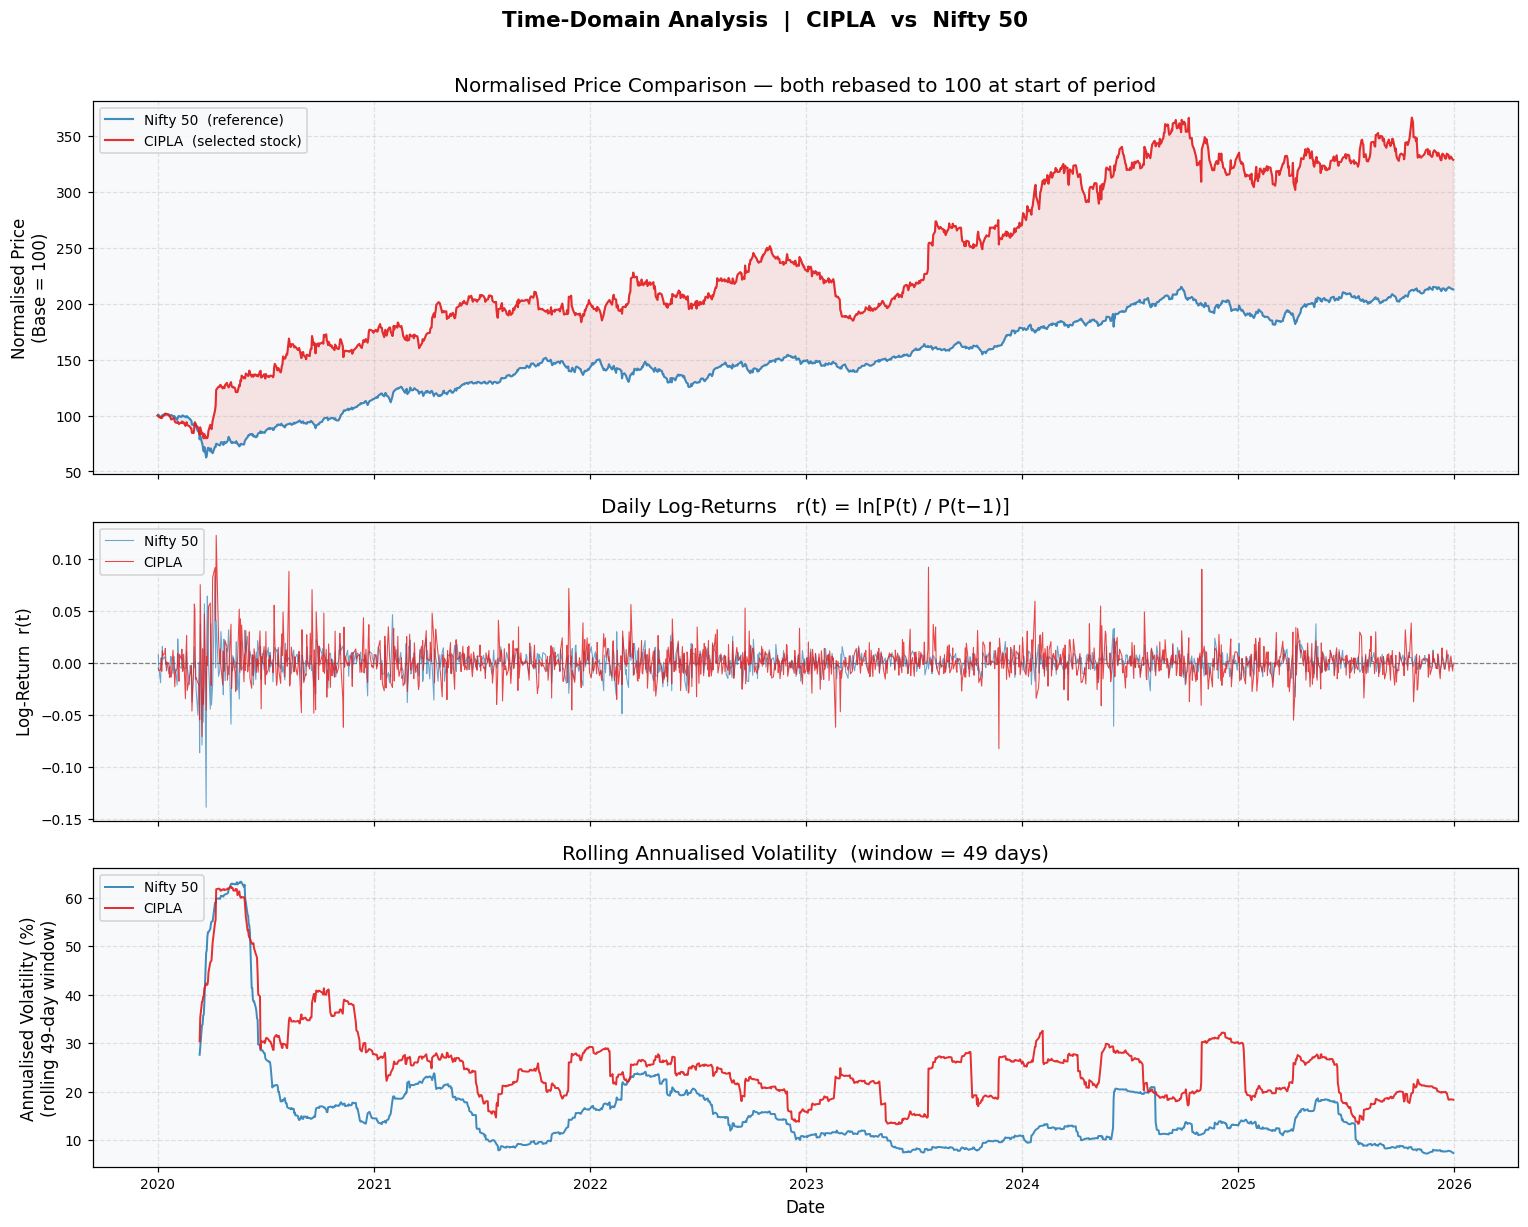

In [78]:
# ── Derived series ───────────────────────────────────────────────────────────
stock_norm  = stock_price / stock_price.iloc[0] * 100
nifty_norm  = nifty_price / nifty_price.iloc[0] * 100

stock_ret   = np.log(stock_price / stock_price.shift(1)).dropna()
nifty_ret   = np.log(nifty_price / nifty_price.shift(1)).dropna()

ROLL_WIN    = max(20, len(stock_ret) // 30)          # ~1 month window
stock_vol   = stock_ret.rolling(ROLL_WIN).std() * np.sqrt(252)
nifty_vol   = nifty_ret.rolling(ROLL_WIN).std() * np.sqrt(252)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={"height_ratios": [2.5, 2, 2]})
fig.suptitle(f"Time-Domain Analysis  |  {STOCK_NAME}  vs  Nifty 50",
             fontsize=14, fontweight="bold", y=1.01)

# Panel 1 – Normalised price
ax = axes[0]
ax.plot(nifty_norm.index, nifty_norm.values, color=REF_COLOR,
        lw=1.4, alpha=0.85, label="Nifty 50  (reference)")
ax.plot(stock_norm.index, stock_norm.values, color=STOCK_COLOR,
        lw=1.4, alpha=0.90, label=f"{STOCK_NAME}  (selected stock)")
ax.set_ylabel("Normalised Price\n(Base = 100)")
ax.set_title("Normalised Price Comparison — both rebased to 100 at start of period")
ax.legend(loc="upper left")
ax.fill_between(stock_norm.index,
                nifty_norm.values, stock_norm.values,
                where=(stock_norm.values >= nifty_norm.values),
                alpha=0.10, color=STOCK_COLOR, label="_nolegend_")
ax.fill_between(stock_norm.index,
                nifty_norm.values, stock_norm.values,
                where=(stock_norm.values < nifty_norm.values),
                alpha=0.10, color=REF_COLOR, label="_nolegend_")

# Panel 2 – Log returns
ax = axes[1]
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.plot(nifty_ret.index, nifty_ret.values, color=REF_COLOR,
        lw=0.7, alpha=0.65, label="Nifty 50")
ax.plot(stock_ret.index, stock_ret.values, color=STOCK_COLOR,
        lw=0.7, alpha=0.80, label=STOCK_NAME)
ax.set_ylabel("Log-Return  r(t)")
ax.set_title("Daily Log-Returns   r(t) = ln[P(t) / P(t−1)]")
ax.legend(loc="upper left")

# Panel 3 – Rolling annualised volatility
ax = axes[2]
ax.plot(nifty_vol.index, nifty_vol.values * 100, color=REF_COLOR,
        lw=1.3, alpha=0.85, label="Nifty 50")
ax.plot(stock_vol.index, stock_vol.values * 100, color=STOCK_COLOR,
        lw=1.3, alpha=0.90, label=STOCK_NAME)
ax.set_ylabel(f"Annualised Volatility (%)\n(rolling {ROLL_WIN}-day window)")
ax.set_xlabel("Date")
ax.set_title(f"Rolling Annualised Volatility  (window = {ROLL_WIN} days)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


---
## Section 2 — Return Distribution & Fat Tails

Mantegna & Stanley showed that financial return distributions display **fat tails** — extreme events occur far more often than a Gaussian model predicts.  
A Lévy stable distribution (with stability index α < 2) better describes the data.

Here we compare the empirical distribution of log-returns against:
- **Normal (Gaussian)** — the efficient-market baseline
- The **empirical excess kurtosis** (> 0 means fat tails)


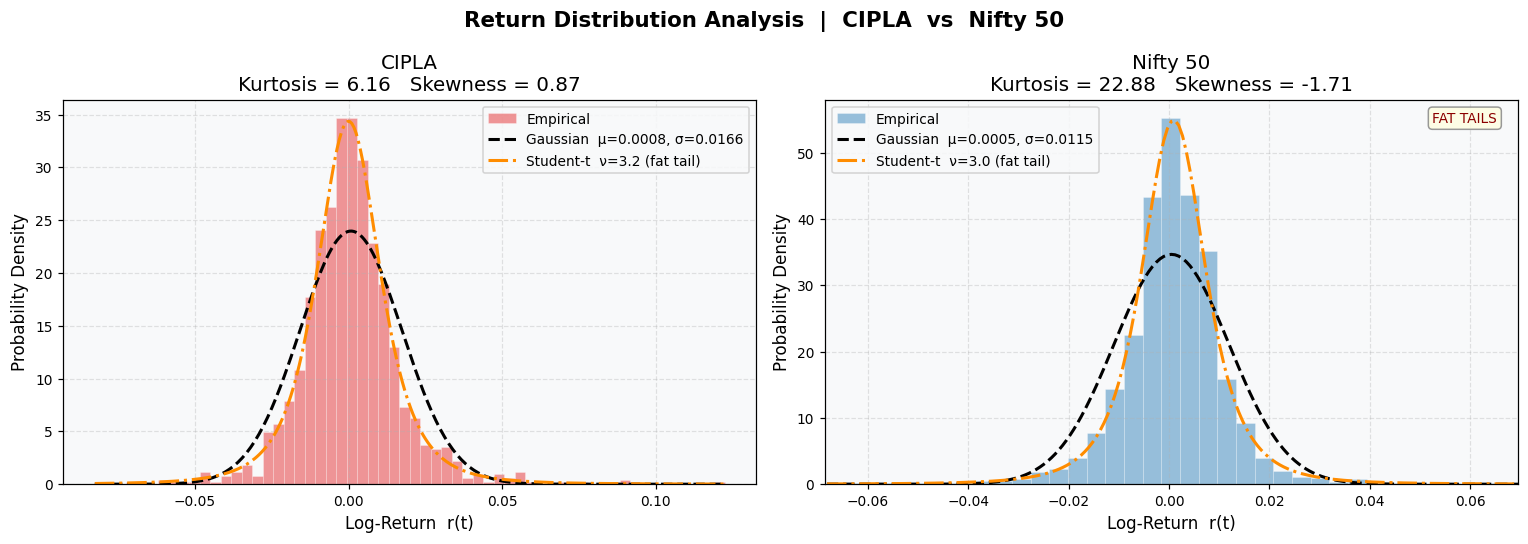

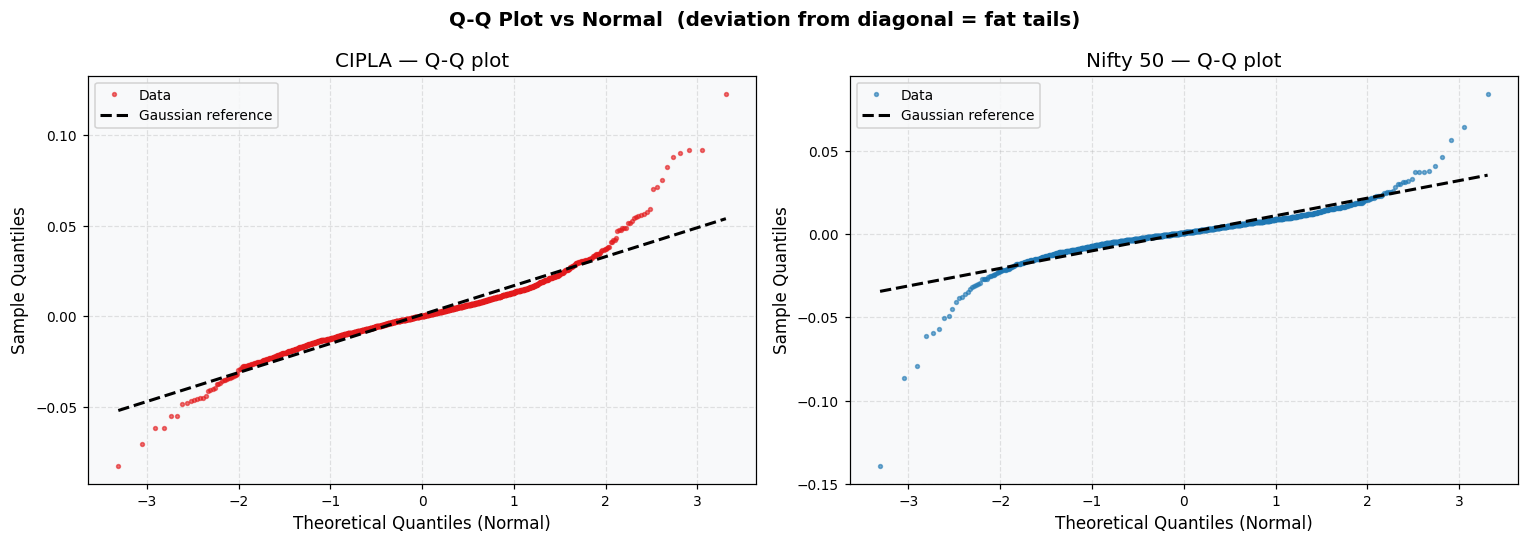

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Return Distribution Analysis  |  {STOCK_NAME}  vs  Nifty 50",
             fontsize=14, fontweight="bold")

bins = max(10, min(60, len(stock_ret) // 10))

for ax, ret, name, col in [
        (axes[0], stock_ret, STOCK_NAME, STOCK_COLOR),
        (axes[1], nifty_ret, "Nifty 50", REF_COLOR)]:

    mu, sigma = ret.mean(), ret.std()
    x_range   = np.linspace(ret.min(), ret.max(), 300)
    gauss     = stats.norm.pdf(x_range, mu, sigma)

    ax.hist(ret, bins=bins, density=True, color=col, alpha=0.45,
            edgecolor="white", linewidth=0.4, label="Empirical")
    ax.plot(x_range, gauss, color="black", lw=2.0, ls="--",
            label=f"Gaussian  μ={mu:.4f}, σ={sigma:.4f}")

    # Fit a Student-t (fat tail proxy)
    nu, t_loc, t_scale = stats.t.fit(ret)
    t_pdf = stats.t.pdf(x_range, nu, t_loc, t_scale)
    ax.plot(x_range, t_pdf, color="darkorange", lw=2.0, ls="-.",
            label=f"Student-t  ν={nu:.1f} (fat tail)")

    kurt = stats.kurtosis(ret)
    skew = stats.skew(ret)
    ax.set_title(f"{name}\nKurtosis = {kurt:.2f}   Skewness = {skew:.2f}")
    ax.set_xlabel("Log-Return  r(t)")
    ax.set_ylabel("Probability Density")
    ax.legend()
    import numpy as np
if not np.isnan(mu) and not np.isnan(sigma) and sigma > 0:
    ax.set_xlim(mu - 6*sigma, mu + 6*sigma)

    # Annotation
    sign = "FAT TAILS" if kurt > 1.0 else ("near-Normal" if kurt < 0.5 else "moderate tails")
    ax.text(0.97, 0.97, sign, transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="darkred",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="grey", alpha=0.8))

plt.tight_layout()
plt.show()

# ── QQ-plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q-Q Plot vs Normal  (deviation from diagonal = fat tails)",
             fontsize=13, fontweight="bold")

for ax, ret, name, col in [
        (axes[0], stock_ret,  STOCK_NAME, STOCK_COLOR),
        (axes[1], nifty_ret, "Nifty 50",  REF_COLOR)]:
    (osm, osr), (slope, intercept, _r) = stats.probplot(ret, dist="norm")
    ax.plot(osm, osr, "o", ms=2.5, color=col, alpha=0.6, label="Data")
    ax.plot(osm, slope*np.array(osm)+intercept, color="black",
            lw=2, ls="--", label="Gaussian reference")
    ax.set_title(f"{name} — Q-Q plot")
    ax.set_xlabel("Theoretical Quantiles (Normal)")
    ax.set_ylabel("Sample Quantiles")
    ax.legend()

plt.tight_layout()
plt.show()


---
## Section 3 — Fourier Power Spectrum  (Turbulence Spectrum)

The **Discrete Fourier Transform** decomposes the price series into constituent frequencies:

$$F(\omega) = \sum_{t=0}^{N-1} f(t)\, e^{-i 2\pi \omega t / N}$$

The **power spectrum** $|F(\omega)|^2$ plotted on a **log–log** scale reveals:

- A **power-law decay** $|F(\omega)|^2 \propto \omega^{-\alpha}$ — the hallmark of **turbulence** and the inertial cascade range (energy transfers from low to high frequencies)
- **White noise** gives a flat spectrum ($\alpha \approx 0$)
- Stock prices typically show $1 \leq \alpha \leq 2$ (between white noise and Brownian motion)

> In fully-developed fluid turbulence (Kolmogorov), $\alpha = 5/3 \approx 1.67$.  
> Stock market turbulence shows a similar but stock-specific exponent.


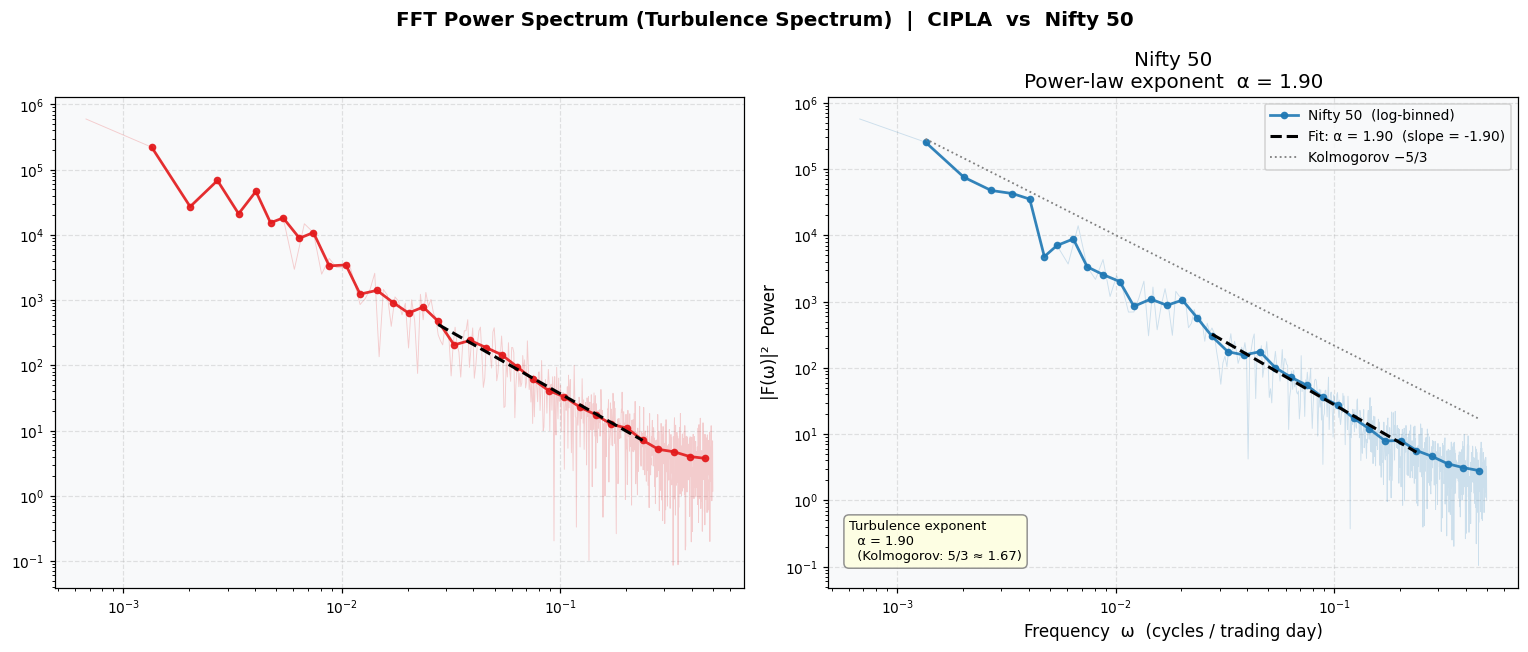

Power-law exponent  α:  CIPLA = 1.898   |   Nifty 50 = 1.902


In [80]:
def power_spectrum(series: pd.Series):
    '''Return (frequencies, power) for a price series.'''
    x  = series.values.astype(float)
    x  = (x - x.mean()) / (x.std() + 1e-12)   # standardise
    F  = np.fft.rfft(x)
    pw = np.abs(F) ** 2
    fr = np.fft.rfftfreq(len(x))
    # Remove DC component
    return fr[1:], pw[1:]

s_freq, s_pow = power_spectrum(stock_price)
n_freq, n_pow = power_spectrum(nifty_price)

# ── Log-log binning (smoother) ────────────────────────────────────────────────
def log_bin(freq, power, n_bins=40):
    bins = np.logspace(np.log10(freq[0]), np.log10(freq[-1]), n_bins + 1)
    f_bin, p_bin = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (freq >= lo) & (freq < hi)
        if mask.sum() > 0:
            f_bin.append(freq[mask].mean())
            p_bin.append(power[mask].mean())
    return np.array(f_bin), np.array(p_bin)

sb_freq, sb_pow = log_bin(s_freq, s_pow)
nb_freq, nb_pow = log_bin(n_freq, n_pow)

# ── Power-law fit ─────────────────────────────────────────────────────────────
def fit_power_law(freq, power, lo_frac=0.05, hi_frac=0.6):
    if len(freq) == 0:
        return 0, 0, np.array([])
    mask = (freq > freq[0] + lo_frac*(freq[-1]-freq[0])) & \
           (freq < freq[0] + hi_frac*(freq[-1]-freq[0]))
    if mask.sum() < 3:
        mask = np.ones(len(freq), dtype=bool)
    lf, lp = np.log10(freq[mask]), np.log10(power[mask])
    slope, intercept = np.polyfit(lf, lp, 1)
    return slope, intercept, freq[mask]

s_slope, s_int, s_fit_f = fit_power_law(sb_freq, sb_pow)
n_slope, n_int, n_fit_f = fit_power_law(nb_freq, nb_pow)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"FFT Power Spectrum (Turbulence Spectrum)  |  {STOCK_NAME}  vs  Nifty 50",
             fontsize=13, fontweight="bold")

for ax, (rf, rp, rbf, rbp, slope, intercept, fit_f, name, col) in enumerate([
    (s_freq, s_pow, sb_freq, sb_pow, s_slope, s_int, s_fit_f, STOCK_NAME, STOCK_COLOR),
    (n_freq, n_pow, nb_freq, nb_pow, n_slope, n_int, n_fit_f, "Nifty 50", REF_COLOR),
]):
    ax_obj = axes[ax]
    # Raw spectrum (light)
    ax_obj.loglog(rf, rp, color=col, alpha=0.20, lw=0.6, label="_nolegend_")
    # Log-binned spectrum
    ax_obj.loglog(rbf, rbp, "o-", color=col, ms=4, lw=1.8,
                  alpha=0.90, label=f"{name}  (log-binned)")
    # Power-law fit
    fit_line = 10**(intercept + slope * np.log10(fit_f))
    ax_obj.loglog(fit_f, fit_line, color="black", lw=2.0, ls="--",
                  label=f"Fit: α = {-slope:.2f}  (slope = {slope:.2f})")
    # Kolmogorov reference: α = 5/3
    # Kolmogorov reference: α = 5/3
if len(rbf) > 0:
    kol_ref = rp.max() * (rbf / rbf[0]) ** (-5/3) * 0.5
    ax_obj.loglog(rbf, kol_ref, color="grey", lw=1.2, ls=":",
                  label="Kolmogorov −5/3")

    ax_obj.set_xlabel("Frequency  ω  (cycles / trading day)")
    ax_obj.set_ylabel("|F(ω)|²  Power")
    ax_obj.set_title(f"{name}\nPower-law exponent  α = {-slope:.2f}")
    ax_obj.legend()

    # Annotation box
    ax_obj.text(0.03, 0.05,
        f"Turbulence exponent\n  α = {-slope:.2f}\n"
        f"  (Kolmogorov: 5/3 ≈ 1.67)",
        transform=ax_obj.transAxes, fontsize=8.5, va="bottom",
        bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="grey", alpha=0.85))

plt.tight_layout()
plt.show()

print(f"Power-law exponent  α:  {STOCK_NAME} = {-s_slope:.3f}   |   Nifty 50 = {-n_slope:.3f}")


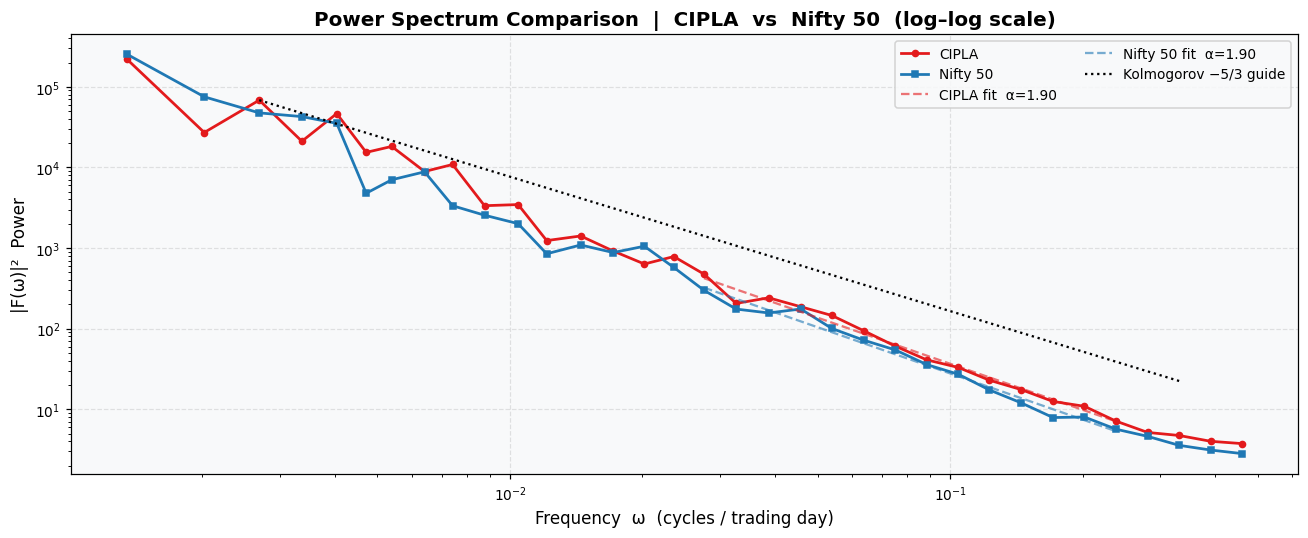

In [81]:
# ── Overlay both spectra on one log-log plot (direct comparison) ─────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title(f"Power Spectrum Comparison  |  {STOCK_NAME}  vs  Nifty 50  (log–log scale)",
             fontsize=13, fontweight="bold")

ax.loglog(sb_freq, sb_pow, "o-", color=STOCK_COLOR, ms=4, lw=1.8, label=STOCK_NAME)
ax.loglog(nb_freq, nb_pow, "s-", color=REF_COLOR,   ms=4, lw=1.8, label="Nifty 50")

s_fit = 10**(s_int + s_slope * np.log10(s_fit_f))
n_fit = 10**(n_int + n_slope * np.log10(n_fit_f))
ax.loglog(s_fit_f, s_fit, color=STOCK_COLOR, lw=1.5, ls="--",
          alpha=0.6, label=f"{STOCK_NAME} fit  α={-s_slope:.2f}")
ax.loglog(n_fit_f, n_fit, color=REF_COLOR,   lw=1.5, ls="--",
          alpha=0.6, label=f"Nifty 50 fit  α={-n_slope:.2f}")

# Kolmogorov −5/3 guide
# Kolmogorov −5/3 guide
if len(sb_freq) > 3:
    kol_x = np.array([sb_freq[2], sb_freq[-3]])
    kol_y = sb_pow[2] * (kol_x / kol_x[0]) ** (-5/3)
    ax.loglog(kol_x, kol_y, "k:", lw=1.5, label="Kolmogorov −5/3 guide")

ax.set_xlabel("Frequency  ω  (cycles / trading day)")
ax.set_ylabel("|F(ω)|²  Power")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


---
## Section 4 — Extended Fourier Transform: Bispectrum

The standard power spectrum $|F(\omega)|^2$ **discards phase information**.  
Two signals can share identical power spectra but differ entirely in their inter-frequency phase relationships.

Sharma et al. (2025) propose the **Extended Fourier Transform (EFT)** — also known as the **bispectrum**:

$$P(\omega_\alpha,\, \omega_\beta) = F(\omega_\alpha)\; F(\omega_\beta)\; F^*(\omega_\alpha + \omega_\beta)$$

| $P(\omega_\alpha, \omega_\beta)$ value | Interpretation |
|---|---|
| **Near zero everywhere** | Phases are mutually independent → **fully-developed turbulence** |
| **Isolated bright spikes** | Phase coupling between specific frequencies → **non-random / manipulated signal** |

### Physical analogy  
In fluid turbulence, energy cascades from large scales to small scales through **nonlinear mode interactions**.  
Fully-developed turbulence has no preferred phase coupling — each mode has its own independent phase.  
A spike in $P(\omega_\alpha, \omega_\beta)$ means that modes $\omega_\alpha$ and $\omega_\beta$ are **"talking" to each other** in a structured way — a fingerprint of artificially planted or systematically biased information.

### Key finding of Sharma et al. (2025)
- **Infosys** displayed pronounced bispectrum spikes → **not fully-developed turbulence**
- All other NSE stocks + Nifty 50 → no such spikes → **consistent with fully-developed turbulence**


In [82]:
def compute_bispectrum(signal: np.ndarray,
                       n_modes: int = 80,
                       n_segments: int = 6) -> np.ndarray:
    '''
    Compute the ensemble-averaged bispectrum magnitude (Welch-style).

    P(ωα, ωβ) = F(ωα) · F(ωβ) · F*(ωα + ωβ)

    Segments the signal, computes the bispectrum for each segment,
    and returns the average magnitude normalised to [0, 1].

    Parameters
    ----------
    signal     : 1-D array of price (or return) values
    n_modes    : number of Fourier modes per axis (N_BSP_MODES)
    n_segments : number of Welch-style segments to average over

    Returns
    -------
    BSP_norm : 2-D array  shape (n_modes, n_modes)  values in [0, 1]
    '''
    N   = len(signal)
    if N < n_segments * 2:
                return np.zeros((n_modes, n_modes), dtype=float)
    seg = N // n_segments
    n   = min(n_modes, seg // 2)

    BSP_acc = np.zeros((n, n), dtype=np.float64)

    for s in range(n_segments):
        chunk = signal[s * seg: (s + 1) * seg].copy()
        chunk = (chunk - chunk.mean()) / (chunk.std() + 1e-12)

        F = np.fft.fft(chunk)          # complex Fourier coefficients

        # Vectorised upper-triangle computation
        for i in range(n):
            j_max = min(n, len(F) - i)
            j_vec = np.arange(i, j_max)
            k_vec = i + j_vec          # ωα + ωβ indices
            vals  = np.abs(F[i] * F[j_vec] * np.conj(F[k_vec]))
            BSP_acc[i, i:j_max] += vals
            BSP_acc[i:j_max, i] += vals   # symmetry

        BSP_acc[np.diag_indices(n)] /= 2  # diagonal counted once

    BSP_avg = BSP_acc / n_segments

    # Normalise to [0, 1]
    mx = BSP_avg.max()
    return (BSP_avg / mx) if mx > 0 else BSP_avg


def phase_coupling_score(BSP: np.ndarray, top_frac: float = 0.01) -> float:
    '''
    Quantify phase coupling: ratio of the top `top_frac` values to the mean.
    High score → concentrated spikes → non-turbulent / structured signal.
    Low score  → uniform / flat      → fully-developed turbulence.
    '''
    flat  = BSP.flatten()
    top_k = max(1, int(len(flat) * top_frac))
    top_v = np.partition(flat, -top_k)[-top_k:]
    return float(top_v.mean() / (flat.mean() + 1e-12))


print("Bispectrum functions defined ✓")
print(f"  Modes per axis : {N_BSP_MODES}")
print(f"  Segments       : {N_SEGMENTS}")
print(f"  Computation    : {N_BSP_MODES}×{N_BSP_MODES} matrix per segment  "
      f"({N_SEGMENTS} segments averaged)")


Bispectrum functions defined ✓
  Modes per axis : 80
  Segments       : 6
  Computation    : 80×80 matrix per segment  (6 segments averaged)


In [83]:
# ── Compute ───────────────────────────────────────────────────────────────────
print(f"Computing bispectrum for {STOCK_NAME} …", end=" ", flush=True)
BSP_stock = compute_bispectrum(stock_price.values, N_BSP_MODES, N_SEGMENTS)
score_s   = phase_coupling_score(BSP_stock)
print(f"done  (phase-coupling score = {score_s:.3f})")

print(f"Computing bispectrum for Nifty 50 …",   end=" ", flush=True)
BSP_nifty = compute_bispectrum(nifty_price.values, N_BSP_MODES, N_SEGMENTS)
score_n   = phase_coupling_score(BSP_nifty)
print(f"done  (phase-coupling score = {score_n:.3f})")


Computing bispectrum for CIPLA … done  (phase-coupling score = 62.372)
Computing bispectrum for Nifty 50 … done  (phase-coupling score = 72.834)


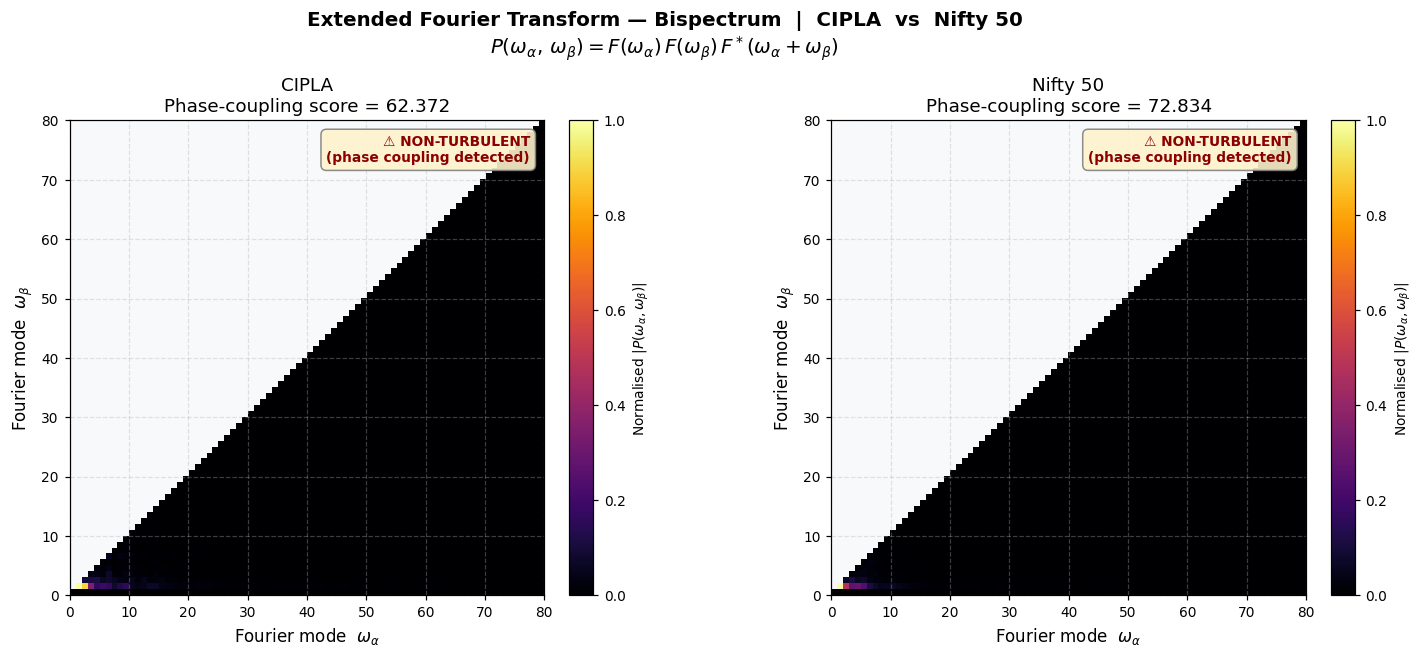

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"Extended Fourier Transform — Bispectrum  |  {STOCK_NAME}  vs  Nifty 50\n"
    r"$P(\omega_\alpha,\, \omega_\beta) = F(\omega_\alpha)\, F(\omega_\beta)\, F^*(\omega_\alpha + \omega_\beta)$",
    fontsize=13, fontweight="bold")



for ax_idx, (BSP, name, col, score) in enumerate([
        (BSP_stock, STOCK_NAME, STOCK_COLOR, score_s),
        (BSP_nifty, "Nifty 50",  REF_COLOR,  score_n)]):

    ax = axes[ax_idx]

    _n = BSP.shape[0]

    # Mask lower triangle (show only the symmetric half)
    mask  = np.zeros_like(BSP)
    mask[np.tril_indices(_n, k=-1)] = np.nan
    BSP_show = BSP + mask

    im = ax.imshow(BSP_show, origin="lower", aspect="equal",
                   cmap=CMAP_BSP, vmin=0, vmax=1,
                   extent=[0, _n, 0, _n])

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"Normalised $|P(\omega_\alpha, \omega_\beta)|$", fontsize=9)

    ax.set_xlabel(r"Fourier mode  $\omega_\alpha$", fontsize=11)
    ax.set_ylabel(r"Fourier mode  $\omega_\beta$",  fontsize=11)
    ax.set_title(f"{name}\nPhase-coupling score = {score:.3f}", fontsize=12)

    # Classification annotation
    threshold = 3.0
    if score > threshold:
        verdict  = "⚠ NON-TURBULENT\n(phase coupling detected)"
        fc_color = "#fff3cd"
        tc_color = "darkred"
    else:
        verdict  = "✓ FULLY-DEVELOPED\nTURBULENCE"
        fc_color = "#d4edda"
        tc_color = "darkgreen"

    ax.text(0.97, 0.97, verdict, transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color=tc_color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", fc=fc_color, ec="grey", alpha=0.90))

plt.tight_layout()
plt.show()


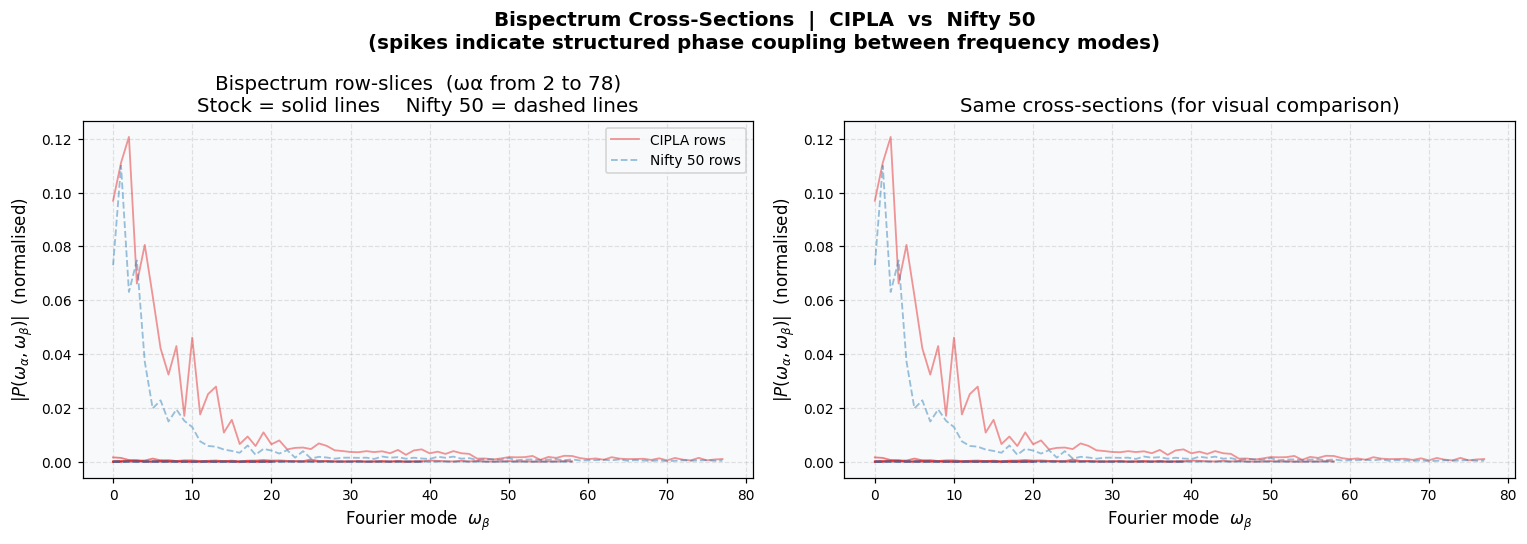

In [85]:
# ── 1-D slice through the bispectrum (diagonal and off-diagonal cuts) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Bispectrum Cross-Sections  |  {STOCK_NAME}  vs  Nifty 50\n"
             "(spikes indicate structured phase coupling between frequency modes)",
             fontsize=13, fontweight="bold")

cuts = {
    "Diagonal  i=j": np.diag(BSP_stock),
    f"Row  ωα=5":    BSP_stock[5, :],
    f"Row  ωα=10":   BSP_stock[10, :],
}

for ax_idx, (BSP, name, col) in enumerate([
        (BSP_stock, STOCK_NAME, STOCK_COLOR),
        (BSP_nifty, "Nifty 50",  REF_COLOR)]):

    ax = axes[ax_idx]
    diag_s = np.diag(BSP_stock); diag_n = np.diag(BSP_nifty)

    # Plot row slices for both on same axes
    n_rows = min(5, BSP_stock.shape[0] // 4)
    row_indices = np.linspace(2, BSP_stock.shape[0] - 2, n_rows, dtype=int)

    for ri, ridx in enumerate(row_indices):
        alpha_val = 0.5 + 0.5 * (ri / len(row_indices))
        ax.plot(BSP_stock[ridx, ridx:], color=STOCK_COLOR, lw=1.2,
                alpha=alpha_val * 0.9,
                label=f"{STOCK_NAME}  ωα={ridx}" if ri == 0 else "_nolegend_")
        ax.plot(BSP_nifty[ridx, ridx:], color=REF_COLOR, lw=1.2,
                alpha=alpha_val * 0.9, ls="--",
                label=f"Nifty 50  ωα={ridx}" if ri == 0 else "_nolegend_")

    ax.set_xlabel(r"Fourier mode  $\omega_\beta$")
    ax.set_ylabel(r"$|P(\omega_\alpha, \omega_\beta)|$  (normalised)")
    ax.set_title(f"Bispectrum row-slices  (ωα from {row_indices[0]} to {row_indices[-1]})\n"
                 f"Stock = solid lines    Nifty 50 = dashed lines")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], [f"{STOCK_NAME} rows", "Nifty 50 rows"],
               loc="upper right")

axes[1].set_xlabel(r"Fourier mode  $\omega_\beta$")
axes[1].set_ylabel(r"$|P(\omega_\alpha, \omega_\beta)|$  (normalised)")
axes[1].set_title("Same cross-sections (for visual comparison)")
# Diagonal comparison
for ax in axes:
    pass

plt.tight_layout()
plt.show()


---
## Section 5 — Turbulence Assessment & Classification

### Framework
In a **fully-developed turbulent** system (fluid or financial market):
1. Energy/amplitude cascades from low frequencies → high frequencies (inertial range)
2. Each Fourier mode has its **own independent phase** — no phase coupling
3. The bispectrum is **flat / noisy** — no concentrated spikes

If instead the bispectrum shows **concentrated spikes**, it means:
- Certain frequency modes are **coupled** (one frequency "drives" another)
- The system is **not** fully-developed turbulent
- In a stock, this signals **systematic information injection** — a structured signal planted inside the price series

### Metric
We use the **phase-coupling score** = (mean of top 1% bispectrum values) / (global mean)

| Score | Classification |
|---|---|
| < 3.0 | Fully-developed turbulence (no significant coupling) |
| 3.0 – 6.0 | Weak coupling — borderline |
| > 6.0 | Strong phase coupling — non-turbulent / structured |


  TURBULENCE CLASSIFICATION REPORT

  Stock          :  CIPLA
  Coupling score :  62.372
  Verdict        :  Strong phase coupling  ⚠

  Reference      :  Nifty 50
  Coupling score :  72.834
  Verdict        :  Strong phase coupling  ⚠



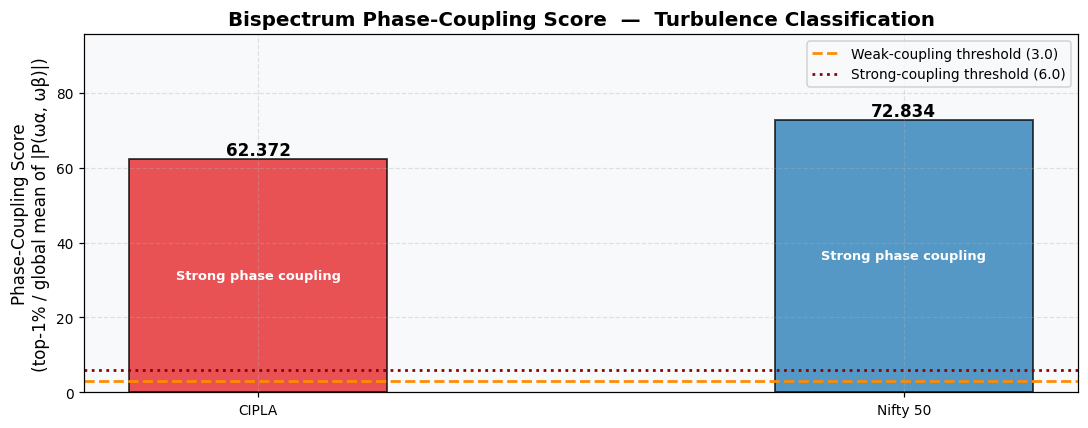

In [86]:
# ── Turbulence classification ─────────────────────────────────────────────────
def classify(score: float) -> tuple[str, str]:
    if score < 3.0:
        return "Fully-developed turbulence  ✓",  "#d4edda"
    elif score < 6.0:
        return "Weak phase coupling  ⚡",          "#fff3cd"
    else:
        return "Strong phase coupling  ⚠",         "#f8d7da"

s_verdict, s_color = classify(score_s)
n_verdict, n_color = classify(score_n)

print("=" * 60)
print("  TURBULENCE CLASSIFICATION REPORT")
print("=" * 60)
print(f"\n  Stock          :  {STOCK_NAME}")
print(f"  Coupling score :  {score_s:.3f}")
print(f"  Verdict        :  {s_verdict}")
print(f"\n  Reference      :  Nifty 50")
print(f"  Coupling score :  {score_n:.3f}")
print(f"  Verdict        :  {n_verdict}")
print("\n" + "=" * 60)

# ── Visual comparison bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
names  = [STOCK_NAME, "Nifty 50"]
scores = [score_s, score_n]
colors = [STOCK_COLOR, REF_COLOR]

bars = ax.bar(names, scores, color=colors, alpha=0.75, edgecolor="black",
              linewidth=1.2, width=0.4)

# Threshold lines
ax.axhline(3.0, color="darkorange", ls="--", lw=1.8,
           label="Weak-coupling threshold (3.0)")
ax.axhline(6.0, color="darkred",    ls=":",  lw=1.8,
           label="Strong-coupling threshold (6.0)")

for bar, score, vc in zip(bars, scores, [s_verdict, n_verdict]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{score:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            vc.split("  ")[0], ha="center", va="center",
            fontsize=8.5, color="white", fontweight="bold")

ax.set_ylabel("Phase-Coupling Score\n(top-1% / global mean of |P(ωα, ωβ)|)")
ax.set_title("Bispectrum Phase-Coupling Score  —  Turbulence Classification",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.set_ylim(0, max(scores) * 1.3 + 1)
plt.tight_layout()
plt.show()


---
## Section 6 — Master Dashboard

A single-figure summary of all analyses — ideal for inclusion in reports or presentations.


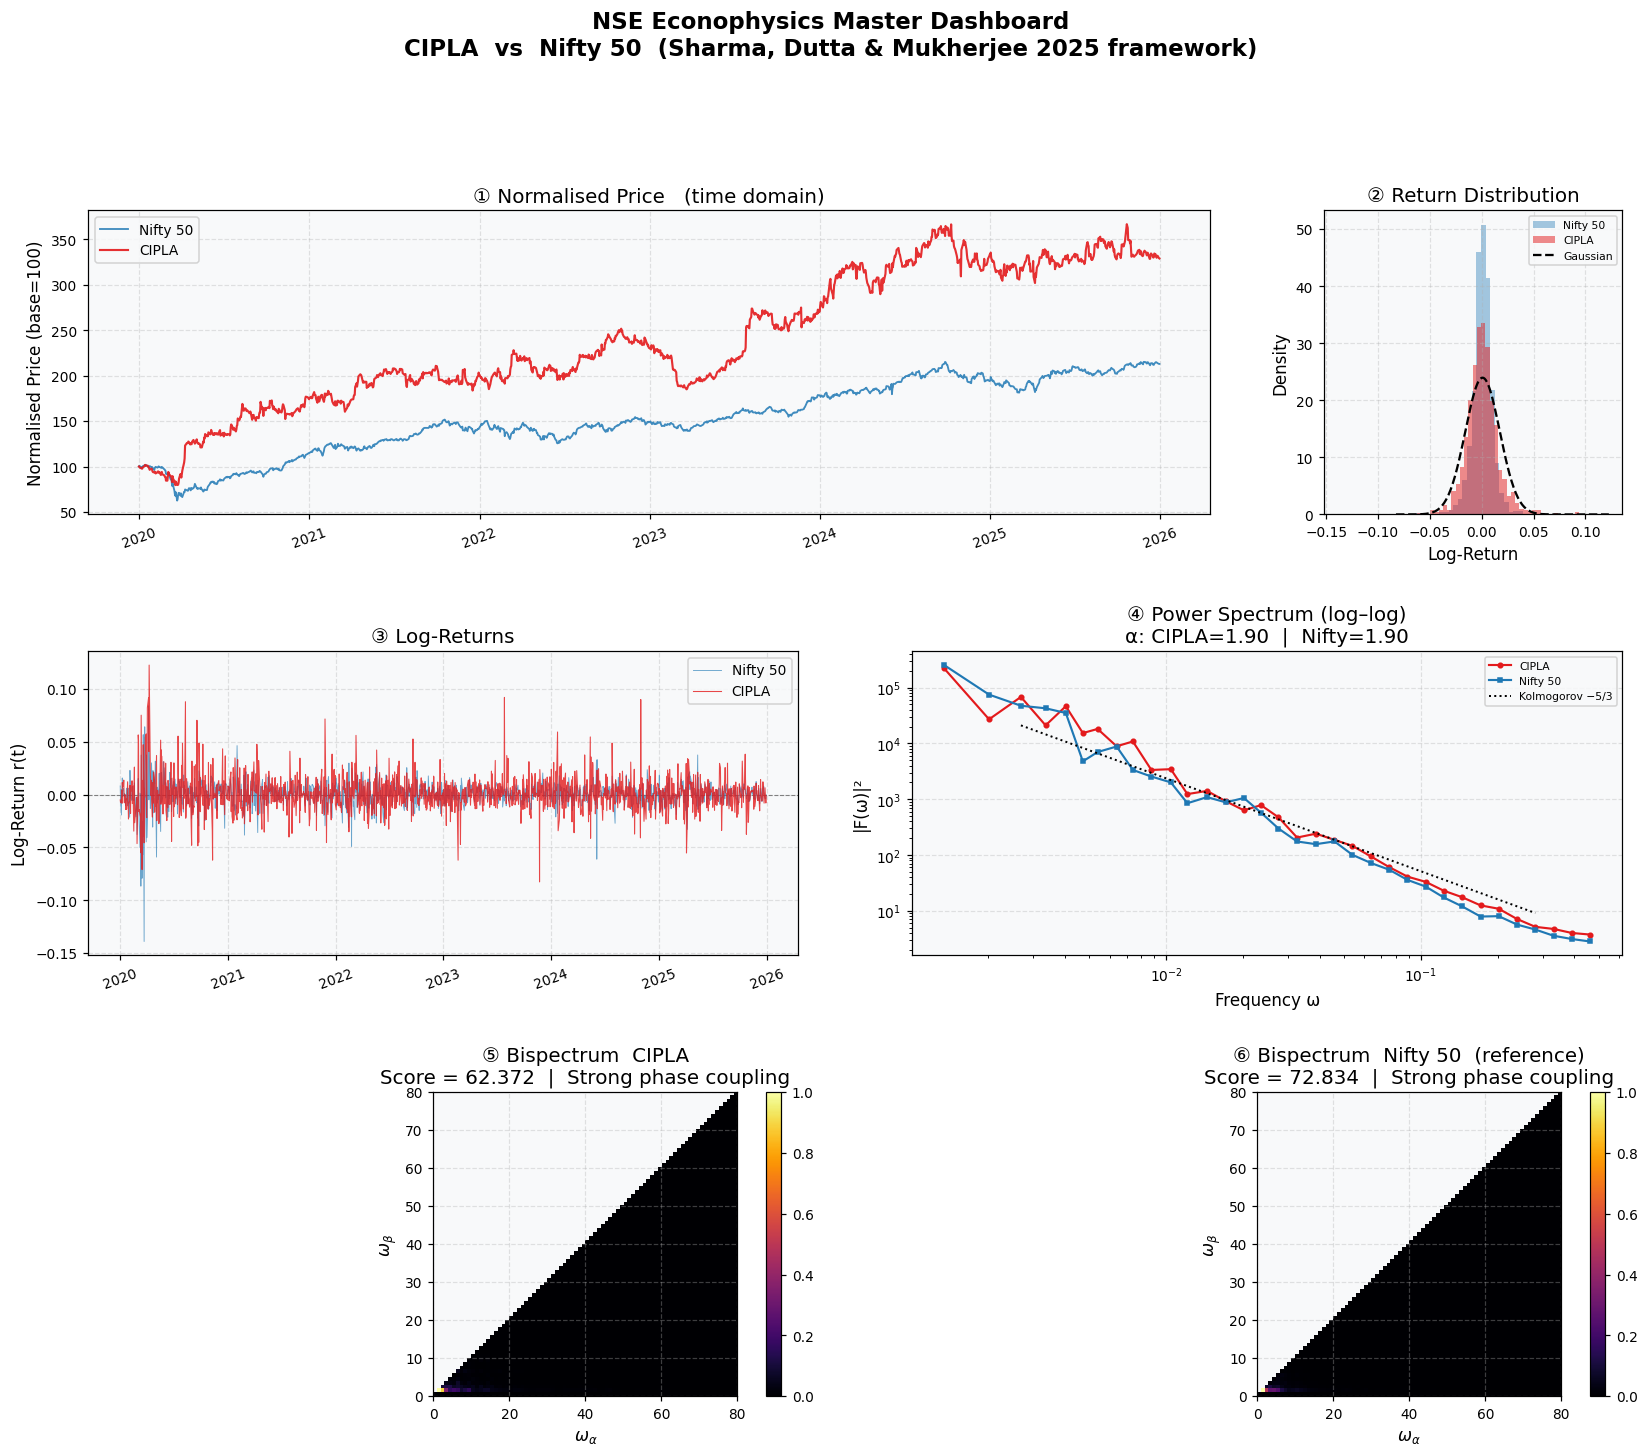

Dashboard saved → nse_data/dashboard_CIPLA.png


In [87]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f"NSE Econophysics Master Dashboard\n{STOCK_NAME}  vs  Nifty 50  "
    f"(Sharma, Dutta & Mukherjee 2025 framework)",
    fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

# ─ Row 0: Normalised price ───────────────────────────────────────────────────
ax_price = fig.add_subplot(gs[0, :3])
ax_price.plot(nifty_norm.index, nifty_norm.values, color=REF_COLOR,
              lw=1.2, alpha=0.85, label="Nifty 50")
ax_price.plot(stock_norm.index, stock_norm.values, color=STOCK_COLOR,
              lw=1.4, alpha=0.90, label=STOCK_NAME)
ax_price.set_ylabel("Normalised Price (base=100)")
ax_price.set_title("① Normalised Price   (time domain)")
ax_price.legend()
ax_price.xaxis.set_tick_params(rotation=20)

# ─ Row 0: Return distribution ────────────────────────────────────────────────
ax_dist = fig.add_subplot(gs[0, 3])
bins = max(10, min(50, len(stock_ret) // 8))
ax_dist.hist(nifty_ret, bins=bins, density=True, color=REF_COLOR,
             alpha=0.40, label="Nifty 50")
ax_dist.hist(stock_ret, bins=bins, density=True, color=STOCK_COLOR,
             alpha=0.50, label=STOCK_NAME)
# Gaussian overlay
x_r = np.linspace(stock_ret.min(), stock_ret.max(), 200)
ax_dist.plot(x_r, stats.norm.pdf(x_r, stock_ret.mean(), stock_ret.std()),
             "k--", lw=1.5, label="Gaussian")
ax_dist.set_xlabel("Log-Return")
ax_dist.set_ylabel("Density")
ax_dist.set_title("② Return Distribution")
ax_dist.legend(fontsize=7)

# ─ Row 1: Log returns ────────────────────────────────────────────────────────
ax_ret = fig.add_subplot(gs[1, :2])
ax_ret.axhline(0, color="grey", lw=0.7, ls="--")
ax_ret.plot(nifty_ret.index, nifty_ret.values, color=REF_COLOR,
            lw=0.6, alpha=0.65, label="Nifty 50")
ax_ret.plot(stock_ret.index, stock_ret.values, color=STOCK_COLOR,
            lw=0.7, alpha=0.80, label=STOCK_NAME)
ax_ret.set_ylabel("Log-Return r(t)")
ax_ret.set_title("③ Log-Returns")
ax_ret.legend()
ax_ret.xaxis.set_tick_params(rotation=20)

# ─ Row 1: FFT power spectrum ─────────────────────────────────────────────────
ax_fft = fig.add_subplot(gs[1, 2:])
ax_fft.loglog(sb_freq, sb_pow, "o-", color=STOCK_COLOR, ms=3, lw=1.4,
              label=STOCK_NAME)
ax_fft.loglog(nb_freq, nb_pow, "s-", color=REF_COLOR,   ms=3, lw=1.4,
              label="Nifty 50")
kol_x = np.array([sb_freq[2], sb_freq[-4]])
kol_y = sb_pow[3] * (kol_x / kol_x[0]) ** (-5/3)
ax_fft.loglog(kol_x, kol_y, "k:", lw=1.3, label="Kolmogorov −5/3")
ax_fft.set_xlabel("Frequency ω")
ax_fft.set_ylabel("|F(ω)|²")
ax_fft.set_title(f"④ Power Spectrum (log–log)\nα: {STOCK_NAME}={-s_slope:.2f}  |  Nifty={-n_slope:.2f}")
ax_fft.legend(fontsize=7)

# ─ Row 2: Bispectrum (stock) ─────────────────────────────────────────────────
ax_bs = fig.add_subplot(gs[2, :2])
_n = BSP_stock.shape[0]
mask_s = np.zeros_like(BSP_stock)
mask_s[np.tril_indices(_n, k=-1)] = np.nan
im1 = ax_bs.imshow(BSP_stock + mask_s, origin="lower", aspect="equal",
                   cmap=CMAP_BSP, vmin=0, vmax=1,
                   extent=[0, _n, 0, _n])
fig.colorbar(im1, ax=ax_bs, fraction=0.046, pad=0.04)
ax_bs.set_xlabel(r"$\omega_\alpha$"); ax_bs.set_ylabel(r"$\omega_\beta$")
ax_bs.set_title(f"⑤ Bispectrum  {STOCK_NAME}\n"
                f"Score = {score_s:.3f}  |  {s_verdict.split('  ')[0]}")

# ─ Row 2: Bispectrum (nifty) ─────────────────────────────────────────────────
ax_bn = fig.add_subplot(gs[2, 2:])
_n = BSP_nifty.shape[0]
mask_n = np.zeros_like(BSP_nifty)
mask_n[np.tril_indices(_n, k=-1)] = np.nan
im2 = ax_bn.imshow(BSP_nifty + mask_n, origin="lower", aspect="equal",
                   cmap=CMAP_BSP, vmin=0, vmax=1,
                   extent=[0, _n, 0, _n])
fig.colorbar(im2, ax=ax_bn, fraction=0.046, pad=0.04)
ax_bn.set_xlabel(r"$\omega_\alpha$"); ax_bn.set_ylabel(r"$\omega_\beta$")
ax_bn.set_title(f"⑥ Bispectrum  Nifty 50  (reference)\n"
                f"Score = {score_n:.3f}  |  {n_verdict.split('  ')[0]}")

plt.savefig(os.path.join(NSE_DATA_DIR, f"dashboard_{STOCK_NAME}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Dashboard saved → {NSE_DATA_DIR}/dashboard_{STOCK_NAME}.png")


---
## Summary & Interpretation Guide

### Reading the results

| Analysis | What to look for | Implication |
|---|---|---|
| **Normalised price** | Stock tracking vs. diverging from Nifty 50 | Alpha generation / sector rotation |
| **Return distribution** | Fat tails (kurtosis >> 0) | Non-Gaussian risk, Lévy-stable regime |
| **Power spectrum slope α** | α ≈ 1.67 (Kolmogorov) | Energy cascade consistent with turbulence |
| **Bispectrum (flat)** | No concentrated spikes | Fully-developed turbulence — no planted information |
| **Bispectrum (spikes)** | Bright streaks / isolated peaks | Phase coupling — structured signal in prices |

### Theoretical interpretation (Sharma et al. 2025)
- A **flat bispectrum** indicates the stock is in the **fully-developed turbulent phase**: price fluctuations are driven by many independent, random information events. This is consistent with Fama's Efficient Market Hypothesis.
- A **spiked bispectrum** (as seen in Infosys 2015–2022) suggests that some frequency modes are systematically coupled: information may have been introduced in a structured, predictable way — either through organised institutional trading, corporate announcements at fixed intervals, or potential market manipulation.

### References
1. Sharma K., Dutta A., Mukherjee R. (2025). *Identification of phase correlations in Financial Stock Market Turbulence*. arXiv:2508.20105
2. Sharma K., Dutta A., Mukherjee R. (2025). *An Analysis of Capital Market through the Lens of Integral Transforms*. arXiv:2506.06350
3. Mantegna R.N., Stanley H.E. (1999). *Introduction to Econophysics*. Cambridge University Press.
4. Kim Y.C., Powers E.J. (1979). *Digital Bispectral Analysis and Its Applications to Nonlinear Wave Interactions*. IEEE Trans. Plasma Science, 7(2):120–131.


In [88]:
print("=" * 62)
print("  FINAL SUMMARY")
print("=" * 62)
print(f"\n  Analysed stock  :  {STOCK_NAME}")
print(f"  Reference index :  Nifty 50 (^NSEI)")
print(f"  Data range      :  {common_idx[0].date()} → {common_idx[-1].date()}")
print(f"  Observations    :  {len(common_idx)} points\n")

print(f"  ① Price performance")
print(f"     {STOCK_NAME:15s}:  {stock_norm.iloc[-1]:7.1f}  (started at 100.0)")
print(f"     {'Nifty 50':15s}:  {nifty_norm.iloc[-1]:7.1f}")
print()
print(f"  ② Volatility (annualised, last reading)")
print(f"     {STOCK_NAME:15s}:  {stock_vol.iloc[-1]*100:6.2f}%")
print(f"     {'Nifty 50':15s}:  {nifty_vol.iloc[-1]*100:6.2f}%")
print()
print(f"  ③ Return distribution kurtosis")
print(f"     {STOCK_NAME:15s}:  {stats.kurtosis(stock_ret):6.2f}")
print(f"     {'Nifty 50':15s}:  {stats.kurtosis(nifty_ret):6.2f}")
print()
print(f"  ④ Power-law exponent α")
print(f"     {STOCK_NAME:15s}:  {-s_slope:6.3f}")
print(f"     {'Nifty 50':15s}:  {-n_slope:6.3f}")
print()
print(f"  ⑤ Bispectrum phase-coupling score")
print(f"     {STOCK_NAME:15s}:  {score_s:6.3f}  →  {s_verdict}")
print(f"     {'Nifty 50':15s}:  {score_n:6.3f}  →  {n_verdict}")
print("=" * 62)


  FINAL SUMMARY

  Analysed stock  :  CIPLA
  Reference index :  Nifty 50 (^NSEI)
  Data range      :  2020-01-01 → 2025-12-30
  Observations    :  1485 points

  ① Price performance
     CIPLA          :    329.0  (started at 100.0)
     Nifty 50       :    212.9

  ② Volatility (annualised, last reading)
     CIPLA          :   18.35%
     Nifty 50       :    7.36%

  ③ Return distribution kurtosis
     CIPLA          :    6.16
     Nifty 50       :   22.88

  ④ Power-law exponent α
     CIPLA          :   1.898
     Nifty 50       :   1.902

  ⑤ Bispectrum phase-coupling score
     CIPLA          :  62.372  →  Strong phase coupling  ⚠
     Nifty 50       :  72.834  →  Strong phase coupling  ⚠
